# HW4 - Imbalanced Learning: Porto Seguro Safe Driver Prediction



## 1. Imports and Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from bayes_opt import BayesianOptimization
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Libraries loaded OK')

Libraries loaded OK


### 3.3 Correlation among continuous features

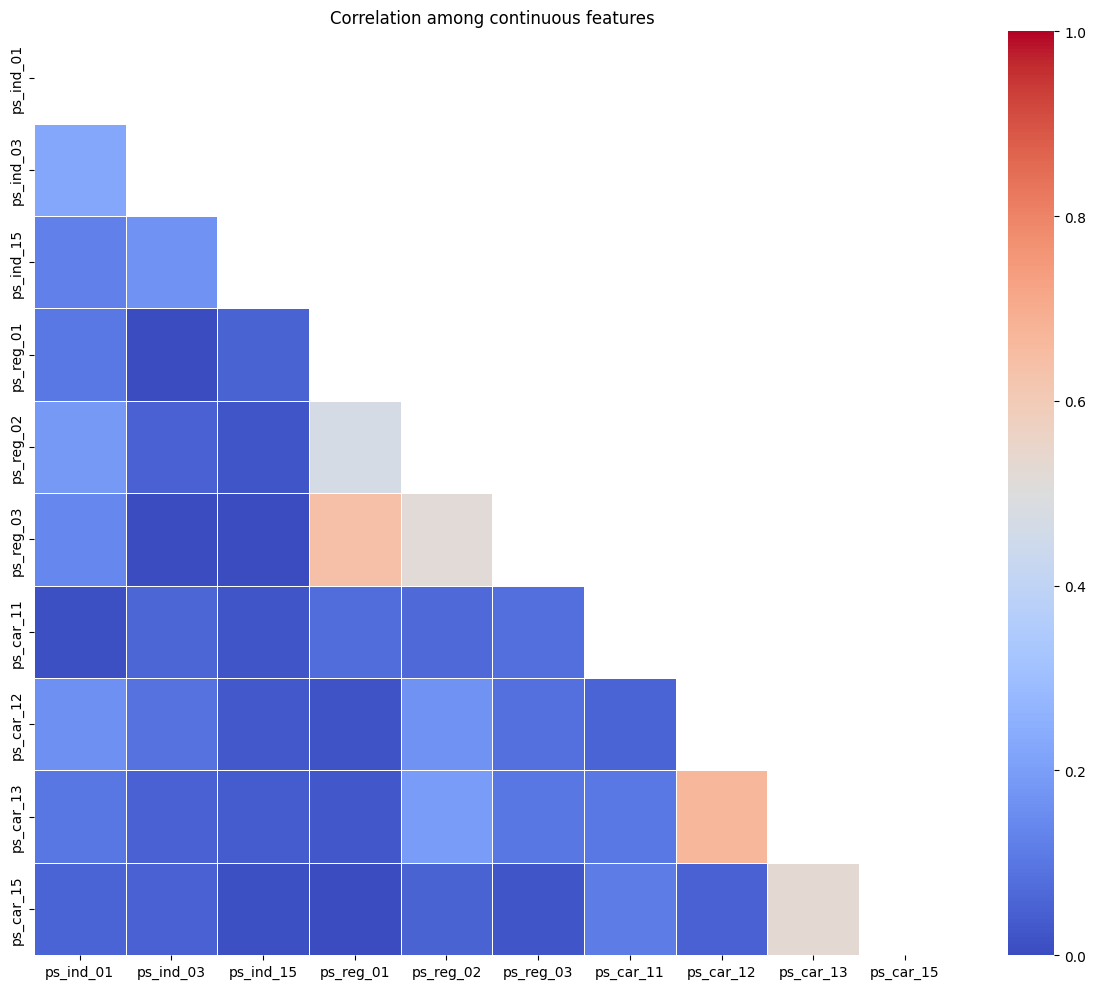

Pairs with correlation > 0.9: []


In [26]:
# Correlation matrix for continuous features
corr_matrix = train[cont_features].corr().abs()

# Plot
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Correlation among continuous features')
plt.tight_layout()
plt.show()

# Identify pairs with correlation > 0.9
upper = corr_matrix.where(mask == False)
high_corr_pairs = [(col, row) 
                   for col in upper.columns 
                   for row in upper.index 
                   if upper.loc[row, col] > 0.9]
print(f'Pairs with correlation > 0.9: {high_corr_pairs}')

### 3.4 Remove features with low discriminative power

In [27]:
# Features to drop based on analysis and instructions:
# - ps_ind_10_bin to ps_ind_13_bin: low variation in target
# - ps_ind_14: low variation
# - ps_car_14: high correlation with another feature
# - all 'calc' features: not discriminative

features_to_drop = [
    'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin',
    'ps_ind_14'
] + calc_features

# Add ps_car_14 if it exists and has high correlation
if 'ps_car_14' in train.columns:
    features_to_drop.append('ps_car_14')

# Keep only existing features
features_to_drop = [f for f in features_to_drop if f in train.columns]

train.drop(columns=features_to_drop, inplace=True)
test.drop(columns=features_to_drop, inplace=True)

print(f'Features dropped: {features_to_drop}')
print(f'Remaining features: {train.shape[1]}')

# Recalculate feature type lists
bin_features  = [c for c in train.columns if c.endswith('_bin')]
cat_features  = [c for c in train.columns if c.endswith('_cat')]
cont_features = [c for c in train.columns 
                 if c not in bin_features + cat_features]

Features dropped: []
Remaining features: 48


### 3.5 Feature: num_missing (count of -1 missing values)

Distribution of num_missing in train:
num_missing
0    140666
1    150719
2    258683
3     45039
4        26
6        21
7        58
Name: count, dtype: int64


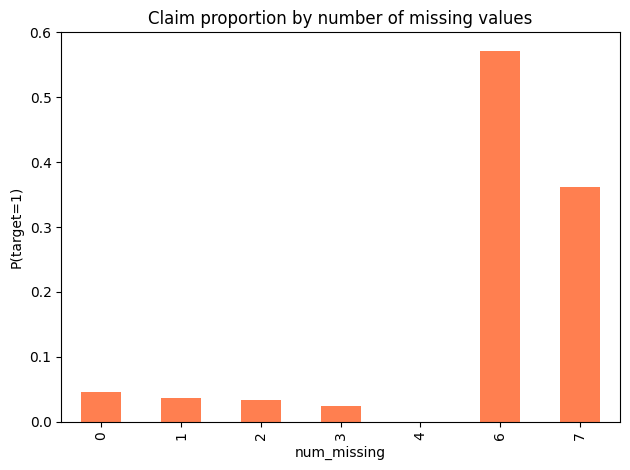

In [28]:
# -1 indicates missing values — counting them can be predictive
train['num_missing'] = (train == -1).sum(axis=1)
test['num_missing']  = (test  == -1).sum(axis=1)

print('Distribution of num_missing in train:')
print(train['num_missing'].value_counts().sort_index())

# Visualize relationship with target
df_miss = pd.DataFrame({'num_missing': train['num_missing'], 'target': target})
df_miss.groupby('num_missing')['target'].mean().plot(kind='bar', color='coral')
plt.title('Claim proportion by number of missing values')
plt.ylabel('P(target=1)')
plt.xlabel('num_missing')
plt.tight_layout()
plt.show()

### 3.6 Feature: mix_ind (combination of ind features)

In [29]:
# Concatenate all 'ind' features into a string (captures interactions)
ind_features = [c for c in train.columns if 'ind' in c and c != 'num_missing']
print(f'Found ind features: {ind_features}')

train['mix_ind'] = train[ind_features].astype(str).apply(
    lambda row: '_'.join(row.values), axis=1
)
test['mix_ind'] = test[ind_features].astype(str).apply(
    lambda row: '_'.join(row.values), axis=1
)

print(f'Unique values in mix_ind (train): {train["mix_ind"].nunique()}')

Found ind features: ['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_15', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'mix_ind', 'ps_ind_02_cat_count', 'ps_ind_04_cat_count', 'ps_ind_05_cat_count', 'mix_ind_count']
Unique values in mix_ind (train): 89185


### 3.7 Count Encoding for categorical features

In [30]:
# For each categorical feature (including mix_ind),
# create a feature with the frequency of each value

cat_to_encode = cat_features + ['mix_ind']

# Combine train and test to compute frequencies on the overall data
combined = pd.concat([train[cat_to_encode], test[cat_to_encode]], axis=0)

for col in cat_to_encode:
    count_map = combined[col].value_counts().to_dict()
    train[col + '_count'] = train[col].map(count_map)
    test[col  + '_count'] = test[col].map(count_map)

print('Applied count encoding to:', cat_to_encode)
print(f'Train shape after count encoding: {train.shape}')

Applied count encoding to: ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'mix_ind']
Train shape after count encoding: (595212, 48)


### 3.8 One-Hot Encoding for nominal categorical features

In [31]:
# One-hot encoding with sklearn (sparse representation for efficiency)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)

# Fit on train, transform train and test
train_cat_ohe = ohe.fit_transform(train[cat_features])
test_cat_ohe  = ohe.transform(test[cat_features])

print(f'Shape OHE train: {train_cat_ohe.shape}')
print(f'Shape OHE test:  {test_cat_ohe.shape}')

Shape OHE train: (595212, 184)
Shape OHE test:  (892816, 184)


### 3.9 Building the final sparse matrix

In [32]:
# Numeric features: continuous + binary + num_missing + count encodings
# Exclude original categorical columns and mix_ind (already represented in OHE and count)
cols_to_exclude = cat_features + ['mix_ind']
num_cols = [c for c in train.columns if c not in cols_to_exclude]

print(f'Final numeric features: {len(num_cols)}')
print(num_cols)

# Replace -1 with NaN for numeric features before feeding to the model
train_num = train[num_cols].replace(-1, np.nan).values.astype(np.float32)
test_num  = test[num_cols].replace(-1, np.nan).values.astype(np.float32)

# Combine into sparse matrix
X_train = sparse.hstack([
    sparse.csr_matrix(train_num),
    train_cat_ohe
], format='csr')

X_test = sparse.hstack([
    sparse.csr_matrix(test_num),
    test_cat_ohe
], format='csr')

y_train = target

print(f'\nX_train final shape: {X_train.shape}')
print(f'X_test  final shape: {X_test.shape}')
print(f'Sparsity: {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.3f}')

Final numeric features: 33
['ps_ind_01', 'ps_ind_03', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_15', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_15', 'num_missing', 'ps_ind_02_cat_count', 'ps_ind_04_cat_count', 'ps_ind_05_cat_count', 'ps_car_01_cat_count', 'ps_car_02_cat_count', 'ps_car_03_cat_count', 'ps_car_04_cat_count', 'ps_car_05_cat_count', 'ps_car_06_cat_count', 'ps_car_07_cat_count', 'ps_car_08_cat_count', 'ps_car_09_cat_count', 'ps_car_10_cat_count', 'ps_car_11_cat_count', 'mix_ind_count']

X_train final shape: (595212, 217)
X_test  final shape: (892816, 217)
Sparsity: 0.811


## 4. Evaluation: Normalized Gini Coefficient

In [33]:
def eval_gini(y_true, y_pred):
    """Calculate the Normalized Gini Coefficient."""
    assert y_true.shape == y_pred.shape
    n_samples = y_true.shape[0]
    L_mid = np.linspace(1 / n_samples, 1, n_samples)  # diagonal line

    # Gini for model predictions
    pred_order = y_true[y_pred.argsort()]
    L_pred = np.cumsum(pred_order) / np.sum(pred_order)
    G_pred = np.sum(L_mid - L_pred)

    # Gini for perfect predictions
    true_order = y_true[y_true.argsort()]
    L_true = np.cumsum(true_order) / np.sum(true_order)
    G_true = np.sum(L_mid - L_true)

    return G_pred / G_true


def gini_lgb(preds, dtrain):
    """Wrapper to use eval_gini as a custom metric in LightGBM."""
    labels = dtrain.get_label()
    return 'gini', eval_gini(labels, preds), True  # True = higher is better


print('Gini functions defined correctly.')
# Quick test
y_test_arr = np.array([0, 0, 1, 0, 1])
y_pred_arr = np.array([0.1, 0.2, 0.8, 0.3, 0.9])
print(f'Test Gini (should be ~1.0): {eval_gini(y_test_arr, y_pred_arr):.4f}')

Gini functions defined correctly.
Test Gini (should be ~1.0): 1.0000


## 5. Model: LightGBM with Stratified K-Fold

In [34]:
# Base parameters (will be optimized with Bayesian Opt in section 6)
# Calculate ratio for scale_pos_weight (negatives / positives)
ratio = float((y_train == 0).sum() / (y_train == 1).sum())
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,
    'num_leaves': 35,
    'lambda_l1': 0.8,
    'lambda_l2': 0.95,
    'feature_fraction': 0.65,
    'bagging_fraction': 0.75,
    'bagging_freq': 1,
    'min_child_samples': 8,
    'min_child_weight': 25,
    'scale_pos_weight': ratio,  # explicit adjustment for imbalance
    'verbose': -1,
    'seed': SEED,
}

N_SPLITS = 5
N_ROUNDS = 2000
EARLY_STOP = 100

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(X_train.shape[0])
test_preds = np.zeros(X_test.shape[0])
gini_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n--- Fold {fold+1}/{N_SPLITS} ---')
    
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    callbacks = [
        lgb.early_stopping(EARLY_STOP, verbose=False),
        lgb.log_evaluation(200)
    ]
    
    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=N_ROUNDS,
        valid_sets=[dval],
        feval=gini_lgb,
        callbacks=callbacks
    )
    
    # OOF and test predictions
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / N_SPLITS
    
    fold_gini = eval_gini(y_val, oof_preds[val_idx])
    gini_scores.append(fold_gini)
    print(f'  Fold Gini: {fold_gini:.5f}')

total_gini = eval_gini(y_train, oof_preds)
print(f'\n=== OOF Gini: {total_gini:.5f} ===')
print(f'Mean CV Gini: {np.mean(gini_scores):.5f} ± {np.std(gini_scores):.5f}')


--- Fold 1/5 ---
[200]	valid_0's auc: 0.640813	valid_0's gini: 0.281626
[400]	valid_0's auc: 0.642973	valid_0's gini: 0.285947
[600]	valid_0's auc: 0.644697	valid_0's gini: 0.289395
[800]	valid_0's auc: 0.645692	valid_0's gini: 0.291384
[1000]	valid_0's auc: 0.646447	valid_0's gini: 0.292894
[1200]	valid_0's auc: 0.646856	valid_0's gini: 0.293712
[1400]	valid_0's auc: 0.64688	valid_0's gini: 0.29376
[1600]	valid_0's auc: 0.647113	valid_0's gini: 0.294226
  Fold Gini: 0.29429

--- Fold 2/5 ---
[200]	valid_0's auc: 0.63622	valid_0's gini: 0.27244
[400]	valid_0's auc: 0.63866	valid_0's gini: 0.27732
[600]	valid_0's auc: 0.640299	valid_0's gini: 0.280599
[800]	valid_0's auc: 0.64129	valid_0's gini: 0.282581
[1000]	valid_0's auc: 0.64177	valid_0's gini: 0.283539
[1200]	valid_0's auc: 0.641876	valid_0's gini: 0.283753
  Fold Gini: 0.28396

--- Fold 3/5 ---
[200]	valid_0's auc: 0.637401	valid_0's gini: 0.274803
[400]	valid_0's auc: 0.639385	valid_0's gini: 0.278771
[600]	valid_0's auc: 0.640

## 6. Hyperparameter Tuning with Bayesian Optimization

In [36]:

def lgb_cv_gini(num_leaves, lambda_l1, lambda_l2,
                feature_fraction, bagging_fraction,
                min_child_samples, min_child_weight):
    """Objective function for Bayesian Optimization."""
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.005,
        'num_leaves': int(num_leaves),
        'lambda_l1': lambda_l1,
        'lambda_l2': lambda_l2,
        'feature_fraction': feature_fraction,
        'bagging_fraction': bagging_fraction,
        'bagging_freq': 1,
        'min_child_samples': int(min_child_samples),
        'min_child_weight': min_child_weight,
        'scale_pos_weight': ratio,
        'verbose': -1,
        'seed': SEED,
    }
    
    skf_bo = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    gini_cv = []
    
    for train_idx, val_idx in skf_bo.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        
        model = lgb.train(
            params, dtrain,
            num_boost_round=1500,  # increased for stability matching final training
            valid_sets=[dval],
            feval=gini_lgb,
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        
        preds_val = model.predict(X_val, num_iteration=model.best_iteration)
        gini_cv.append(eval_gini(y_val, preds_val))
    
    return np.mean(gini_cv)


# Search space per assignment
pbounds = {
    'num_leaves':        (30, 40),
    'lambda_l1':         (0.7, 0.9),
    'lambda_l2':         (0.9, 1.0),
    'feature_fraction':  (0.6, 0.7),
    'bagging_fraction':  (0.6, 0.9),
    'min_child_samples': (6, 10),
    'min_child_weight':  (10, 40),
}

optimizer = BayesianOptimization(
    f=lgb_cv_gini,
    pbounds=pbounds,
    random_state=SEED,
    verbose=2
)

# Run optimization (init_points: random explorations, n_iter: Bayesian iterations)
optimizer.maximize(init_points=5, n_iter=15)

print('\nBest parameters found:')
print(optimizer.max)

|   iter    |  target   | num_le... | lambda_l1 | lambda_l2 | featur... | baggin... | min_ch... | min_ch... |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.2852953 | 33.745401 | 0.8901428 | 0.9731993 | 0.6598658 | 0.6468055 | 6.6239780 | 11.742508 |
| 2         | 0.2851658 | 38.661761 | 0.8202230 | 0.9708072 | 0.6020584 | 0.8909729 | 9.3297705 | 16.370173 |
| 3         | 0.2856531 | 31.818249 | 0.7366809 | 0.9304242 | 0.6524756 | 0.7295835 | 7.1649165 | 28.355586 |
| 4         | 0.2856790 | 31.394938 | 0.7584289 | 0.9366361 | 0.6456069 | 0.8355527 | 6.7986951 | 25.427033 |
| 5         | 0.2860511 | 35.924145 | 0.7092900 | 0.9607544 | 0.6170524 | 0.6195154 | 9.7955421 | 38.968960 |
| 6         | 0.2859444 | 39.978229 | 0.7378035 | 0.9760670 | 0.6382741 | 0.6826576 | 6.0444204 | 38.754015 |
| 7         | 0.2861920 | 30.113943 | 0.8854088 | 0.9558781 | 0.6339502 | 0.7882466 | 6.1035331 | 39.744081 |
| 8       

### 6.1 Re-train with best parameters

In [38]:
# Extract best parameters
best_params = optimizer.max['params']

final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,
    'num_leaves': int(best_params['num_leaves']),
    'lambda_l1': best_params['lambda_l1'],
    'lambda_l2': best_params['lambda_l2'],
    'feature_fraction': best_params['feature_fraction'],
    'bagging_fraction': best_params['bagging_fraction'],
    'bagging_freq': 1,
    'min_child_samples': int(best_params['min_child_samples']),
    'min_child_weight': best_params['min_child_weight'],
    'scale_pos_weight': ratio,
    'verbose': -1,
    'seed': SEED,
}

print('Final parameters:', final_params)

# Re-train with 5-fold and optimized parameters
oof_preds_final  = np.zeros(X_train.shape[0])
test_preds_final = np.zeros(X_test.shape[0])
gini_final = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n--- Fold {fold+1}/{N_SPLITS} ---')
    
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    model = lgb.train(
        final_params, dtrain,
        num_boost_round=N_ROUNDS,
        valid_sets=[dval],
        feval=gini_lgb,
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(200)
        ]
    )
    
    oof_preds_final[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds_final += model.predict(X_test, num_iteration=model.best_iteration) / N_SPLITS
    
    g = eval_gini(y_val, oof_preds_final[val_idx])
    gini_final.append(g)
    print(f'  Fold Gini: {g:.5f}')

print(f'\n=== OOF Gini Final: {eval_gini(y_train, oof_preds_final):.5f} ===')
print(f'Mean CV Gini: {np.mean(gini_final):.5f} ± {np.std(gini_final):.5f}')

Final parameters: {'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.005, 'num_leaves': 31, 'lambda_l1': np.float64(0.8433506755378043), 'lambda_l2': np.float64(0.9254414486721183), 'feature_fraction': np.float64(0.6088141954126542), 'bagging_fraction': np.float64(0.8482625048290078), 'bagging_freq': 1, 'min_child_samples': 7, 'min_child_weight': np.float64(39.876923676954554), 'scale_pos_weight': 26.43671061122891, 'verbose': -1, 'seed': 42}

--- Fold 1/5 ---
[200]	valid_0's auc: 0.640631	valid_0's gini: 0.281262
[400]	valid_0's auc: 0.642665	valid_0's gini: 0.28533
[600]	valid_0's auc: 0.644245	valid_0's gini: 0.288489
[800]	valid_0's auc: 0.645345	valid_0's gini: 0.29069
[1000]	valid_0's auc: 0.645936	valid_0's gini: 0.291872
[1200]	valid_0's auc: 0.646398	valid_0's gini: 0.292795
[1400]	valid_0's auc: 0.646731	valid_0's gini: 0.293462
[1600]	valid_0's auc: 0.646919	valid_0's gini: 0.293837
  Fold Gini: 0.29388

--- Fold 2/5 ---
[200]	valid_0's auc: 0.635848	valid_0's gini:

## 7. Submission File for Kaggle

In [ ]:
test_preds_final = np.clip(test_preds_final, 0.0, 1.0).astype(np.float32)

submission = pd.DataFrame({
    'id': test_id,
    'target': test_preds_final
})

submission = submission[['id', 'target']]
submission.to_csv('submission_final5.csv', index=False)

print('submission_final5.csv created!')
print(submission.head(10))
print(f'\nPrediction statistics:')
print(submission['target'].describe())

Archivo submission.csv creado!
   id    target
0   0  0.418523
1   1  0.373737
2   2  0.403511
3   3  0.261716
4   4  0.500366
5   5  0.562835
6   6  0.363152
7   8  0.431478
8  10  0.602848
9  11  0.586911

Estadísticas de predicciones:
count    892816.000000
mean          0.460665
std           0.115266
min           0.118720
25%           0.378024
50%           0.458548
75%           0.540190
max           0.901709
Name: target, dtype: float64
